<a href="https://colab.research.google.com/github/akash-321/hate-speech-detection-RAG/blob/main/notebooks/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning BERT for Hate Speech Detection on the MHS Dataset
  Dissertation: Investigation of Hate Speech Detection Model through religious lens.

  This notebook: data checks, model training, and test predictions.
  
  Comparison with IMSyPP is done in model_comparison.ipynb.
  

In [1]:
!pip install datasets pandas numpy matplotlib seaborn krippendorff emoji wandb

In [2]:
!pip -q install -U transformers datasets accelerate evaluate

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/dissertation"
os.makedirs(SAVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

FIG_DIR = "/content/drive/MyDrive/dissertation/figures"
import os; os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

### Imports and reproducibility (fixed seed 42)

In [5]:
import krippendorff
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.model_selection import train_test_split

import os, random, torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

## Load Pre-split Data
Load the train, test, and validation CSV files produced by `data_splitting.ipynb`.

In [6]:
train_df = pd.read_csv("/content/drive/MyDrive/dissertation/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/dissertation/test.csv")
val_df = pd.read_csv("/content/drive/MyDrive/dissertation/val.csv")

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Val rows:", len(val_df))


Train rows: 9581
Test rows: 3782
Val rows: 2493


### Data leakage check

In [7]:
train_ids = set(train_df["comment_id"])
test_ids = set(test_df["comment_id"])
val_ids = set(val_df["comment_id"])

print("Train ∩ Test:", len(train_ids & test_ids))
print("Train ∩ Val :", len(train_ids & val_ids))
print("Test  ∩ Val :", len(test_ids & val_ids))

assert not (train_ids & test_ids), "LEAKAGE: comments shared between train and test!"
assert not (train_ids & val_ids),"LEAKAGE: comments shared between train and test!"
assert not (test_ids & val_ids),"LEAKAGE: comments shared between train and test!"
print("Splits are clean at comment level")

Train ∩ Test: 0
Train ∩ Val : 0
Test  ∩ Val : 0
Splits are clean at comment level


## Religion group definitions

In [8]:
annotator_religions = ["muslim", "christian", "jewish", "atheist", "buddhist"]
target_religions = ["muslim", "christian", "jewish", "atheist", "buddhist"]

df5 = pd.concat([train_df, test_df, val_df], ignore_index=True)

### Building final percentage tables from 5 religion groups

In [9]:
def make_table(data):
    table = pd.DataFrame()
    for a in annotator_religions:
        row = {}
        sub_a = data[data["annotator_group"] == a]
        for t in target_religions:
            sub = sub_a[sub_a["target_group"] == t]
            total = len(sub)
            if total > 0:
                hate = round(sub["is_hate_speech"].mean() * 100, 2)
                non = round(100 - hate, 2)
            else:
                hate = np.nan
                non = np.nan
            row[f"% Hate - {t.capitalize()}"] = hate
            row[f"% Non-Hate - {t.capitalize()}"] = non
        table = pd.concat([table, pd.DataFrame(row, index=[a.capitalize()+" annotators"])])
    return table

In [10]:
def make_table_b(df, title):
    s = df.style.format("{:.2f}").set_caption(title)
    hate_cols = [c for c in df.columns if "Hate -" in c]
    non_cols = [c for c in df.columns if "Non-Hate -" in c]
    s = s.set_properties(subset=hate_cols, **{"font-weight": "bold"})
    s = s.set_properties(subset=non_cols, **{"color": "gray"})
    s = s.background_gradient(axis=None)
    return s

In [11]:
full_table = make_table(df5)
train_table = make_table(train_df)
test_table = make_table(test_df)
val_table = make_table(val_df)

display(make_table_b(full_table, "Full Dataset: Hate vs Non-Hate (%)"))
display(make_table_b(train_table, "Train (70%)"))
display(make_table_b(test_table, "Test (20%)"))
display(make_table_b(val_table, "Validation (10%)"))

,% Hate - Muslim,% Non-Hate - Muslim,% Hate - Christian,% Non-Hate - Christian,% Hate - Jewish,% Non-Hate - Jewish,% Hate - Atheist,% Non-Hate - Atheist,% Hate - Buddhist,% Non-Hate - Buddhist
Muslim annotators,33.02,66.98,12.82,87.18,75.68,24.32,20.00,80.00,nan,nan
Christian annotators,40.79,59.21,13.82,86.18,72.45,27.55,19.67,80.33,20.83,79.17
Jewish annotators,44.06,55.94,12.82,87.18,74.17,25.83,16.67,83.33,0.00,100.00
Atheist annotators,43.22,56.78,10.96,89.04,73.47,26.53,19.75,80.25,9.09,90.91
Buddhist annotators,38.33,61.67,11.22,88.78,69.70,30.30,0.00,100.00,100.00,0.00


,% Hate - Muslim,% Non-Hate - Muslim,% Hate - Christian,% Non-Hate - Christian,% Hate - Jewish,% Non-Hate - Jewish,% Hate - Atheist,% Non-Hate - Atheist,% Hate - Buddhist,% Non-Hate - Buddhist
Muslim annotators,37.84,62.16,9.68,90.32,37.50,62.50,33.33,66.67,nan,nan
Christian annotators,44.48,55.52,12.35,87.65,47.75,52.25,18.55,81.45,23.53,76.47
Jewish annotators,46.77,53.23,7.55,92.45,59.62,40.38,33.33,66.67,0.00,100.00
Atheist annotators,46.34,53.66,9.57,90.43,51.81,48.19,21.82,78.18,14.29,85.71
Buddhist annotators,41.44,58.56,10.81,89.19,42.86,57.14,0.00,100.00,nan,nan


,% Hate - Muslim,% Non-Hate - Muslim,% Hate - Christian,% Non-Hate - Christian,% Hate - Jewish,% Non-Hate - Jewish,% Hate - Atheist,% Non-Hate - Atheist,% Hate - Buddhist,% Non-Hate - Buddhist
Muslim annotators,31.82,68.18,28.57,71.43,76.92,23.08,0.00,100.00,nan,nan
Christian annotators,46.75,53.25,20.83,79.17,81.91,18.09,26.83,73.17,25.00,75.00
Jewish annotators,57.69,42.31,20.00,80.00,77.78,22.22,0.00,100.00,nan,nan
Atheist annotators,49.68,50.32,16.00,84.00,83.96,16.04,16.67,83.33,0.00,100.00
Buddhist annotators,45.65,54.35,6.67,93.33,78.57,21.43,0.00,100.00,nan,nan


,% Hate - Muslim,% Non-Hate - Muslim,% Hate - Christian,% Non-Hate - Christian,% Hate - Jewish,% Non-Hate - Jewish,% Hate - Atheist,% Non-Hate - Atheist,% Hate - Buddhist,% Non-Hate - Buddhist
Muslim annotators,0.00,100.00,0.00,100.00,93.75,6.25,nan,nan,nan,nan
Christian annotators,10.48,89.52,13.64,86.36,89.99,10.01,11.11,88.89,0.00,100.00
Jewish annotators,3.85,96.15,30.00,70.00,93.75,6.25,0.00,100.00,nan,nan
Atheist annotators,12.12,87.88,13.25,86.75,89.86,10.14,12.50,87.50,0.00,100.00
Buddhist annotators,8.70,91.30,22.22,77.78,88.24,11.76,0.00,100.00,100.00,0.00


### Count version of the table (Hate and Non-Hate)

In [12]:
def make_count_table(data):
    counts = (
        data.groupby(["annotator_group", "target_group"]).size().unstack(fill_value=0).reindex(index=annotator_religions, columns=target_religions, fill_value=0)
    )
    counts.index = [x.capitalize() + " annotators" for x in counts.index]
    counts.columns = [x.capitalize() for x in counts.columns]
    return counts

print("FULL COUNTS ")
display(make_count_table(df5))
print("TRAIN COUNTS ")
display(make_count_table(train_df))
print("TEST COUNTS ")
display(make_count_table(test_df))
print("VAL COUNTS ")
display(make_count_table(val_df))

FULL COUNTS 


,Muslim,Christian,Jewish,Atheist,Buddhist
Muslim annotators,106,39,37,5,0
Christian annotators,5241,2402,2200,183,24
Jewish annotators,202,78,120,6,1
Atheist annotators,2580,1031,1161,81,11
Buddhist annotators,180,98,66,3,1


TRAIN COUNTS 


,Muslim,Christian,Jewish,Atheist,Buddhist
Muslim annotators,74,31,8,3,0
Christian annotators,3377,1798,779,124,17
Jewish annotators,124,53,52,3,1
Atheist annotators,1653,773,442,55,7
Buddhist annotators,111,74,21,1,0


TEST COUNTS 


,Muslim,Christian,Jewish,Atheist,Buddhist
Muslim annotators,22,7,13,2,0
Christian annotators,1215,384,702,41,4
Jewish annotators,52,15,36,1,0
Atheist annotators,630,175,374,18,1
Buddhist annotators,46,15,28,1,0


VAL COUNTS 


,Muslim,Christian,Jewish,Atheist,Buddhist
Muslim annotators,10,1,16,0,0
Christian annotators,649,220,719,18,3
Jewish annotators,26,10,32,2,0
Atheist annotators,297,83,345,8,3
Buddhist annotators,23,9,17,1,1


### Count version of table - Hate / Non-Hate

In [13]:
def make_count_hate_nonhate_table(data):
    table = pd.DataFrame()
    for a in annotator_religions:
        row = {}
        sub_a = data[data["annotator_group"] == a]
        for t in target_religions:
            sub = sub_a[sub_a["target_group"] == t]
            hate_n = int(sub["is_hate_speech"].sum())
            total = len(sub)
            non_n = total - hate_n
            row[f"Hate (n) \u2192 {t.capitalize()}"]     = hate_n
            row[f"Non-Hate (n) \u2192 {t.capitalize()}"] = non_n
        table = pd.concat([table, pd.DataFrame(row, index=[a.capitalize()+" annotators"])])
    return table

full_count_table = make_count_hate_nonhate_table(df5)
train_count_table = make_count_hate_nonhate_table(train_df)
test_count_table = make_count_hate_nonhate_table(test_df)
val_count_table = make_count_hate_nonhate_table(val_df)

In [14]:
def style_count_table(df, title):
    return (
        df.style.format("{:,.0f}").set_caption(title).set_table_styles([
            {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]},
            {"selector": "th", "props": [("background-color", "#f2f2f2"), ("font-weight", "bold")]}
        ])
        .background_gradient(cmap="Blues", axis=None)
    )

In [15]:
display(style_count_table(full_count_table, "Full Dataset: Hate / Non-Hate (Counts)"))
display(style_count_table(train_count_table, "Train (70%) - Counts"))
display(style_count_table(test_count_table, "Test (20%) - Counts"))
display(style_count_table(val_count_table, "Validation (10%) - Counts"))

,Hate (n) → Muslim,Non-Hate (n) → Muslim,Hate (n) → Christian,Non-Hate (n) → Christian,Hate (n) → Jewish,Non-Hate (n) → Jewish,Hate (n) → Atheist,Non-Hate (n) → Atheist,Hate (n) → Buddhist,Non-Hate (n) → Buddhist
Muslim annotators,35,71,5,34,28,9,1,4,0,0
Christian annotators,"2,138","3,103",332,"2,070","1,594",606,36,147,5,19
Jewish annotators,89,113,10,68,89,31,1,5,0,1
Atheist annotators,"1,115","1,465",113,918,853,308,16,65,1,10
Buddhist annotators,69,111,11,87,46,20,0,3,1,0


,Hate (n) → Muslim,Non-Hate (n) → Muslim,Hate (n) → Christian,Non-Hate (n) → Christian,Hate (n) → Jewish,Non-Hate (n) → Jewish,Hate (n) → Atheist,Non-Hate (n) → Atheist,Hate (n) → Buddhist,Non-Hate (n) → Buddhist
Muslim annotators,28,46,3,28,3,5,1,2,0,0
Christian annotators,"1,502","1,875",222,"1,576",372,407,23,101,4,13
Jewish annotators,58,66,4,49,31,21,1,2,0,1
Atheist annotators,766,887,74,699,229,213,12,43,1,6
Buddhist annotators,46,65,8,66,9,12,0,1,0,0


,Hate (n) → Muslim,Non-Hate (n) → Muslim,Hate (n) → Christian,Non-Hate (n) → Christian,Hate (n) → Jewish,Non-Hate (n) → Jewish,Hate (n) → Atheist,Non-Hate (n) → Atheist,Hate (n) → Buddhist,Non-Hate (n) → Buddhist
Muslim annotators,7,15,2,5,10,3,0,2,0,0
Christian annotators,568,647,80,304,575,127,11,30,1,3
Jewish annotators,30,22,3,12,28,8,0,1,0,0
Atheist annotators,313,317,28,147,314,60,3,15,0,1
Buddhist annotators,21,25,1,14,22,6,0,1,0,0


,Hate (n) → Muslim,Non-Hate (n) → Muslim,Hate (n) → Christian,Non-Hate (n) → Christian,Hate (n) → Jewish,Non-Hate (n) → Jewish,Hate (n) → Atheist,Non-Hate (n) → Atheist,Hate (n) → Buddhist,Non-Hate (n) → Buddhist
Muslim annotators,0,10,0,1,15,1,0,0,0,0
Christian annotators,68,581,30,190,647,72,2,16,0,3
Jewish annotators,1,25,3,7,30,2,0,2,0,0
Atheist annotators,36,261,11,72,310,35,1,7,0,3
Buddhist annotators,2,21,2,7,15,2,0,1,1,0


### COUNT AND PERCENTAGE TOGETHER VERSION OF TABLE

In [16]:
def make_combined_table(data):
    table = pd.DataFrame()
    for a in annotator_religions:
        row = {}
        sub_a = data[data["annotator_group"] == a]
        for t in target_religions:
            sub = sub_a[sub_a["target_group"] == t]
            total = len(sub)
            hate_n = int(sub["is_hate_speech"].sum())
            non_n  = total - hate_n
            if total > 0:
                hate_pct = hate_n / total * 100
                non_pct = non_n / total * 100
                hate_text = f"{hate_pct:.2f}% ({hate_n}/{total})"
                non_text = f"{non_pct:.2f}% ({non_n}/{total})"
            else:
                hate_text = "\u2014"
                non_text = "\u2014"
            row[f"% Hate - {t.capitalize()}"] = hate_text
            row[f"% Non-Hate - {t.capitalize()}"] = non_text
        table = pd.concat([table, pd.DataFrame(row, index=[a.capitalize() + " annotators"])])
    return table

full_combined = make_combined_table(df5)
train_combined = make_combined_table(train_df)
test_combined = make_combined_table(test_df)
val_combined = make_combined_table(val_df)

In [17]:
def style_combined(df, title):
    return (
        df.style.set_caption(title).set_table_styles([
            {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold")]},
            {"selector": "th", "props": [("background-color", "#f2f2f2"), ("font-weight", "bold")]},
            {"selector": "td", "props": [("font-family", "Arial"),         ("font-size", "12px")]}
        ])
    )

display(style_combined(full_combined, "Full Dataset: Hate vs Non-Hate (%, counts)"))
display(style_combined(train_combined, "Train (70%): Hate vs Non-Hate (%, counts)"))
display(style_combined(test_combined, "Test (20%): Hate vs Non-Hate (%, counts)"))
display(style_combined(val_combined, "Validation (10%): Hate vs Non-Hate (%, counts)"))

,% Hate - Muslim,% Non-Hate - Muslim,% Hate - Christian,% Non-Hate - Christian,% Hate - Jewish,% Non-Hate - Jewish,% Hate - Atheist,% Non-Hate - Atheist,% Hate - Buddhist,% Non-Hate - Buddhist
Muslim annotators,33.02% (35/106),66.98% (71/106),12.82% (5/39),87.18% (34/39),75.68% (28/37),24.32% (9/37),20.00% (1/5),80.00% (4/5),—,—
Christian annotators,40.79% (2138/5241),59.21% (3103/5241),13.82% (332/2402),86.18% (2070/2402),72.45% (1594/2200),27.55% (606/2200),19.67% (36/183),80.33% (147/183),20.83% (5/24),79.17% (19/24)
Jewish annotators,44.06% (89/202),55.94% (113/202),12.82% (10/78),87.18% (68/78),74.17% (89/120),25.83% (31/120),16.67% (1/6),83.33% (5/6),0.00% (0/1),100.00% (1/1)
Atheist annotators,43.22% (1115/2580),56.78% (1465/2580),10.96% (113/1031),89.04% (918/1031),73.47% (853/1161),26.53% (308/1161),19.75% (16/81),80.25% (65/81),9.09% (1/11),90.91% (10/11)
Buddhist annotators,38.33% (69/180),61.67% (111/180),11.22% (11/98),88.78% (87/98),69.70% (46/66),30.30% (20/66),0.00% (0/3),100.00% (3/3),100.00% (1/1),0.00% (0/1)


,% Hate - Muslim,% Non-Hate - Muslim,% Hate - Christian,% Non-Hate - Christian,% Hate - Jewish,% Non-Hate - Jewish,% Hate - Atheist,% Non-Hate - Atheist,% Hate - Buddhist,% Non-Hate - Buddhist
Muslim annotators,37.84% (28/74),62.16% (46/74),9.68% (3/31),90.32% (28/31),37.50% (3/8),62.50% (5/8),33.33% (1/3),66.67% (2/3),—,—
Christian annotators,44.48% (1502/3377),55.52% (1875/3377),12.35% (222/1798),87.65% (1576/1798),47.75% (372/779),52.25% (407/779),18.55% (23/124),81.45% (101/124),23.53% (4/17),76.47% (13/17)
Jewish annotators,46.77% (58/124),53.23% (66/124),7.55% (4/53),92.45% (49/53),59.62% (31/52),40.38% (21/52),33.33% (1/3),66.67% (2/3),0.00% (0/1),100.00% (1/1)
Atheist annotators,46.34% (766/1653),53.66% (887/1653),9.57% (74/773),90.43% (699/773),51.81% (229/442),48.19% (213/442),21.82% (12/55),78.18% (43/55),14.29% (1/7),85.71% (6/7)
Buddhist annotators,41.44% (46/111),58.56% (65/111),10.81% (8/74),89.19% (66/74),42.86% (9/21),57.14% (12/21),0.00% (0/1),100.00% (1/1),—,—


,% Hate - Muslim,% Non-Hate - Muslim,% Hate - Christian,% Non-Hate - Christian,% Hate - Jewish,% Non-Hate - Jewish,% Hate - Atheist,% Non-Hate - Atheist,% Hate - Buddhist,% Non-Hate - Buddhist
Muslim annotators,31.82% (7/22),68.18% (15/22),28.57% (2/7),71.43% (5/7),76.92% (10/13),23.08% (3/13),0.00% (0/2),100.00% (2/2),—,—
Christian annotators,46.75% (568/1215),53.25% (647/1215),20.83% (80/384),79.17% (304/384),81.91% (575/702),18.09% (127/702),26.83% (11/41),73.17% (30/41),25.00% (1/4),75.00% (3/4)
Jewish annotators,57.69% (30/52),42.31% (22/52),20.00% (3/15),80.00% (12/15),77.78% (28/36),22.22% (8/36),0.00% (0/1),100.00% (1/1),—,—
Atheist annotators,49.68% (313/630),50.32% (317/630),16.00% (28/175),84.00% (147/175),83.96% (314/374),16.04% (60/374),16.67% (3/18),83.33% (15/18),0.00% (0/1),100.00% (1/1)
Buddhist annotators,45.65% (21/46),54.35% (25/46),6.67% (1/15),93.33% (14/15),78.57% (22/28),21.43% (6/28),0.00% (0/1),100.00% (1/1),—,—


,% Hate - Muslim,% Non-Hate - Muslim,% Hate - Christian,% Non-Hate - Christian,% Hate - Jewish,% Non-Hate - Jewish,% Hate - Atheist,% Non-Hate - Atheist,% Hate - Buddhist,% Non-Hate - Buddhist
Muslim annotators,0.00% (0/10),100.00% (10/10),0.00% (0/1),100.00% (1/1),93.75% (15/16),6.25% (1/16),—,—,—,—
Christian annotators,10.48% (68/649),89.52% (581/649),13.64% (30/220),86.36% (190/220),89.99% (647/719),10.01% (72/719),11.11% (2/18),88.89% (16/18),0.00% (0/3),100.00% (3/3)
Jewish annotators,3.85% (1/26),96.15% (25/26),30.00% (3/10),70.00% (7/10),93.75% (30/32),6.25% (2/32),0.00% (0/2),100.00% (2/2),—,—
Atheist annotators,12.12% (36/297),87.88% (261/297),13.25% (11/83),86.75% (72/83),89.86% (310/345),10.14% (35/345),12.50% (1/8),87.50% (7/8),0.00% (0/3),100.00% (3/3)
Buddhist annotators,8.70% (2/23),91.30% (21/23),22.22% (2/9),77.78% (7/9),88.24% (15/17),11.76% (2/17),0.00% (0/1),100.00% (1/1),100.00% (1/1),0.00% (0/1)


### Row Distribution

In [18]:
total_rows = len(df5)
train_pct = len(train_df) / total_rows * 100
test_pct = len(test_df) / total_rows * 100
val_pct = len(val_df) / total_rows * 100
print("ROW DISTRIBUTION ")
print(f"Train : {len(train_df)} rows ({train_pct:.2f}%)")
print(f"Test : {len(test_df)} rows ({test_pct:.2f}%)")
print(f"Val : {len(val_df)} rows ({val_pct:.2f}%)")
print(f"Total after split : {len(train_df)+len(test_df)+len(val_df)}")
print(f"Original rows : {total_rows}")

ROW DISTRIBUTION 
Train : 9581 rows (60.43%)
Test : 3782 rows (23.85%)
Val : 2493 rows (15.72%)
Total after split : 15856
Original rows : 15856


## Installing libraries for BERT fine-tuning

#### transformers, accelerate, evaluate already installed above

#### Build comment-level training data and 3-class labels
##### `label_3`: 0=counter (< -1), 1=neutral (-1 to 0.5), 2=hate (> 0.5)

## Text preprocessing (lowercase, URLs, mentions, emoji translation)

In [19]:

import re, emoji

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_comment_level(df_split: pd.DataFrame) -> pd.DataFrame:
    c = (
        df_split.groupby("comment_id").agg(
            text=("text", "first"),
            mean_score=("hate_speech_score", "mean"),
            n_annotations=("hate_speech_score", "size")
        )
        .reset_index()
    )
    c["text"] = c["text"].map(preprocess)
    c["label_3"] = np.select(
        [
            c["mean_score"] < -1,
            c["mean_score"] <= 0.5
        ],
        [0, 1],
        default=2
    ).astype(int)
    return c

train_c = build_comment_level(train_df)
print("Train examples (comment-level):", len(train_c))
train_c["label_3"].value_counts()

Train examples (comment-level): 3795


,count
label_3,
0,1818
1,1105
2,872


### Score distribution threshold

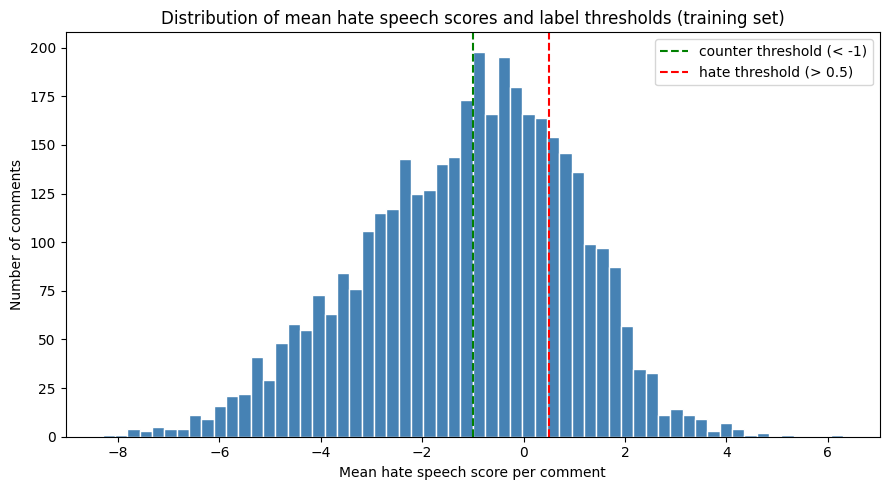

In [20]:
plt.figure(figsize=(9, 5))
plt.hist(train_c["mean_score"], bins=60, color="steelblue", edgecolor="white")
plt.axvline(-1,  color="green", linestyle="--", label="counter threshold (< -1)")
plt.axvline(0.5, color="red",   linestyle="--", label="hate threshold (> 0.5)")
plt.xlabel("Mean hate speech score per comment")
plt.ylabel("Number of comments")
plt.title("Distribution of mean hate speech scores and label thresholds (training set)")
plt.legend()
save_fig("score_distribution_thresholds")

### Top words hate vs neutral

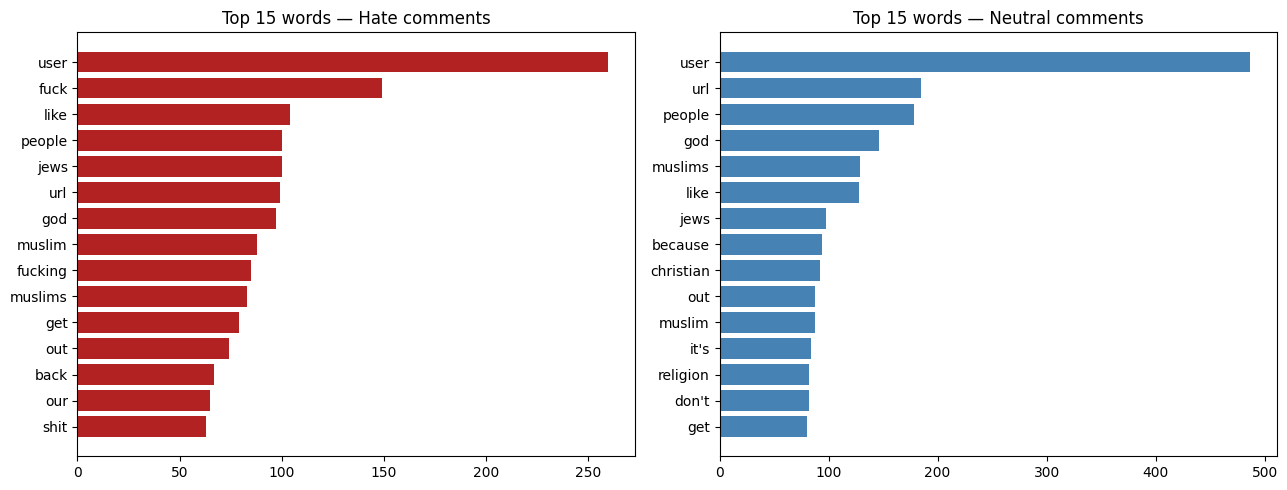

In [21]:
from collections import Counter
import re

stop = set("""the a an and or but of to in on for is are was were be been it its this that
those these i you he she they we my your their his her them us not no do does did with as
at by from so if would could should can will just have has had what when who all""".split())

def top_words(texts, n=15):
    counter = Counter()
    for t in texts:
        words = re.findall(r"[a-z']{3,}", str(t).lower())
        counter.update(w for w in words if w not in stop)
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, title, color) in zip(axes, [(2, "Hate comments", "firebrick"),
                                            (1, "Neutral comments", "steelblue")]):
    tw = top_words(train_c[train_c["label_3"] == label]["text"])
    ax.barh(tw["word"][::-1], tw["count"][::-1], color=color)
    ax.set_title(f"Top 15 words — {title}")
save_fig("top_words_hate_vs_neutral")

In [22]:
train_df

,comment_id,annotator_id,platform,sentiment,respect,insult,humiliate,status,dehumanize,violence,...,annotator_religion_nothing,annotator_religion_other,annotator_sexuality_bisexual,annotator_sexuality_gay,annotator_sexuality_straight,annotator_sexuality_other,is_hate_speech,annotator_group,target_group,strat_bin
0,32374,5521,2,4.0,3.0,2.0,2.0,3.0,2.0,1.0,...,False,False,False,False,False,True,0,atheist,muslim,atheist|muslim|0
1,20844,1782,2,3.0,4.0,3.0,3.0,2.0,2.0,3.0,...,False,False,False,False,True,False,0,christian,christian,christian|christian|0
2,48594,5266,3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,False,False,False,False,True,False,0,christian,muslim,christian|muslim|0
3,17090,3691,0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,True,False,0,christian,christian,christian|christian|0
4,5391,10716,0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,...,False,False,False,False,True,False,0,christian,muslim,christian|muslim|0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9576,20064,9905,1,1.0,1.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,True,False,0,atheist,muslim,atheist|muslim|0
9577,20064,10290,1,1.0,0.0,0.0,0.0,2.0,0.0,0.0,...,False,False,True,False,False,False,0,christian,muslim,christian|muslim|0
9578,22986,7440,2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,False,False,False,False,True,False,0,christian,muslim,christian|muslim|0
9579,21008,5449,2,3.0,2.0,1.0,1.0,2.0,1.0,1.0,...,False,False,False,False,True,False,0,atheist,muslim,atheist|muslim|0


### Tokenizing the training data for BERT

In [23]:
from datasets import Dataset
from transformers import AutoTokenizer

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_ds = Dataset.from_pandas(
    train_c[["text", "label_3"]].rename(columns={"label_3": "labels"})
)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

train_ds = train_ds.map(tokenize, batched=True)
train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
train_ds

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/3795 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3795
})

### Training BERT (bert-base-uncased) - first baseline search

In [24]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, logging
logging.set_verbosity_error()

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

training_args = TrainingArguments(
    output_dir="distilbert_train_only",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="epoch",
    report_to="none",
    dataloader_pin_memory=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds
)

trainer.train()

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{'loss': '1.004', 'grad_norm': '3.733', 'learning_rate': '1.863e-05', 'epoch': '0.2101'}
{'loss': '0.8342', 'grad_norm': '10.72', 'learning_rate': '1.723e-05', 'epoch': '0.4202'}
{'loss': '0.7959', 'grad_norm': '6.967', 'learning_rate': '1.583e-05', 'epoch': '0.6303'}
{'loss': '0.7744', 'grad_norm': '5.641', 'learning_rate': '1.443e-05', 'epoch': '0.8403'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.4978', 'grad_norm': '9.811', 'learning_rate': '6.022e-06', 'epoch': '2.101'}
{'loss': '0.4456', 'grad_norm': '6.67', 'learning_rate': '4.622e-06', 'epoch': '2.311'}
{'loss': '0.3897', 'grad_norm': '9.927', 'learning_rate': '3.221e-06', 'epoch': '2.521'}
{'loss': '0.417', 'grad_norm': '9.297', 'learning_rate': '1.821e-06', 'epoch': '2.731'}
{'loss': '0.4077', 'grad_norm': '14.06', 'learning_rate': '4.202e-07', 'epoch': '2.941'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '511.3', 'train_samples_per_second': '22.27', 'train_steps_per_second': '1.396', 'train_loss': '0.6175', 'epoch': '3'}


TrainOutput(global_step=714, training_loss=0.617545432403308, metrics={'train_runtime': 511.3159, 'train_samples_per_second': 22.266, 'train_steps_per_second': 1.396, 'train_loss': 0.617545432403308, 'epoch': 3.0})

### Preparing validation set (comment-level) and tokenizing

In [25]:
val_c = build_comment_level(val_df)
print("Val examples (comment-level):", len(val_c))
print(val_c["label_3"].value_counts())

from datasets import Dataset

val_ds = Dataset.from_pandas(
    val_c[["text", "label_3"]].rename(columns={"label_3": "labels"})
)
val_ds = val_ds.map(tokenize, batched=True)
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_ds

Val examples (comment-level): 549
label_3
0    254
1    166
2    129
Name: count, dtype: int64


Map:   0%|          | 0/549 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 549
})

### Validating the trained model (accuracy + F1)

In [26]:
import evaluate
acc = evaluate.load("accuracy")
f1  = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds,  references=labels, average="macro")["f1"],
        "f1_weighted": f1.compute(predictions=preds,  references=labels, average="weighted")["f1"],
    }

trainer.compute_metrics = compute_metrics
trainer.eval_dataset = val_ds
trainer.evaluate()

{'eval_loss': '0.8642', 'eval_accuracy': '0.6302', 'eval_f1_macro': '0.6041', 'eval_f1_weighted': '0.629', 'eval_runtime': '8.055', 'eval_samples_per_second': '68.16', 'eval_steps_per_second': '8.566', 'epoch': '3'}


{'eval_loss': 0.8641797304153442,
 'eval_accuracy': 0.6302367941712204,
 'eval_f1_macro': 0.6040882268037916,
 'eval_f1_weighted': 0.6290197570406203,
 'eval_runtime': 8.0551,
 'eval_samples_per_second': 68.156,
 'eval_steps_per_second': 8.566,
 'epoch': 3.0}

### Re-training with validation monitoring and save the best checkpoint

In [27]:
from transformers import (
    AutoModelForSequenceClassification, TrainingArguments, Trainer,
    logging, EarlyStoppingCallback
)
logging.set_verbosity_error()

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
SEED  = 42

training_args = TrainingArguments(
    output_dir="distilbert_with_val_best",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    dataloader_pin_memory=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback()]
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{'loss': '1.037', 'grad_norm': '5.245', 'learning_rate': '1.863e-05', 'epoch': '0.2101'}
{'loss': '0.926', 'grad_norm': '9.664', 'learning_rate': '1.723e-05', 'epoch': '0.4202'}
{'loss': '0.828', 'grad_norm': '6.234', 'learning_rate': '1.583e-05', 'epoch': '0.6303'}
{'loss': '0.8003', 'grad_norm': '5.932', 'learning_rate': '1.443e-05', 'epoch': '0.8403'}
{'eval_loss': '0.8079', 'eval_accuracy': '0.5993', 'eval_f1_macro': '0.5498', 'eval_f1_weighted': '0.5832', 'eval_runtime': '7.872', 'eval_samples_per_second': '69.75', 'eval_steps_per_second': '2.287', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.7731', 'grad_norm': '4.509', 'learning_rate': '1.303e-05', 'epoch': '1.05'}
{'loss': '0.6799', 'grad_norm': '4.09', 'learning_rate': '1.162e-05', 'epoch': '1.261'}
{'loss': '0.6501', 'grad_norm': '10.22', 'learning_rate': '1.022e-05', 'epoch': '1.471'}
{'loss': '0.6464', 'grad_norm': '16.26', 'learning_rate': '8.824e-06', 'epoch': '1.681'}
{'loss': '0.643', 'grad_norm': '7.697', 'learning_rate': '7.423e-06', 'epoch': '1.891'}
{'eval_loss': '0.7907', 'eval_accuracy': '0.612', 'eval_f1_macro': '0.5812', 'eval_f1_weighted': '0.6056', 'eval_runtime': '7.901', 'eval_samples_per_second': '69.48', 'eval_steps_per_second': '2.278', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.5516', 'grad_norm': '7.843', 'learning_rate': '6.022e-06', 'epoch': '2.101'}
{'loss': '0.4886', 'grad_norm': '8.801', 'learning_rate': '4.622e-06', 'epoch': '2.311'}
{'loss': '0.4613', 'grad_norm': '18.15', 'learning_rate': '3.221e-06', 'epoch': '2.521'}
{'loss': '0.4719', 'grad_norm': '10.81', 'learning_rate': '1.821e-06', 'epoch': '2.731'}
{'loss': '0.472', 'grad_norm': '9.664', 'learning_rate': '4.202e-07', 'epoch': '2.941'}
{'eval_loss': '0.832', 'eval_accuracy': '0.6284', 'eval_f1_macro': '0.602', 'eval_f1_weighted': '0.6253', 'eval_runtime': '7.908', 'eval_samples_per_second': '69.42', 'eval_steps_per_second': '2.276', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '528.9', 'train_samples_per_second': '21.53', 'train_steps_per_second': '1.35', 'train_loss': '0.6695', 'epoch': '3'}


TrainOutput(global_step=714, training_loss=0.669455408048229, metrics={'train_runtime': 528.8845, 'train_samples_per_second': 21.526, 'train_steps_per_second': 1.35, 'train_loss': 0.669455408048229, 'epoch': 3.0})

### Validating once more using the best checkpoint

In [28]:
trainer.evaluate()

{'eval_loss': '0.832', 'eval_accuracy': '0.6284', 'eval_f1_macro': '0.602', 'eval_f1_weighted': '0.6253', 'eval_runtime': '7.674', 'eval_samples_per_second': '71.54', 'eval_steps_per_second': '2.346', 'epoch': '3'}


{'eval_loss': 0.8319684267044067,
 'eval_accuracy': 0.6284153005464481,
 'eval_f1_macro': 0.6019886806403659,
 'eval_f1_weighted': 0.6253059475875219,
 'eval_runtime': 7.674,
 'eval_samples_per_second': 71.54,
 'eval_steps_per_second': 2.346,
 'epoch': 3.0}

## Improved model

#### Rebuilding tokenization with longer max length

In [29]:
MAX_LEN = 256

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

from transformers import DataCollatorWithPadding
collator = DataCollatorWithPadding(tokenizer)

from datasets import Dataset

train_ds = Dataset.from_pandas(train_c[["text", "label_3"]].rename(columns={"label_3": "labels"}))
val_ds = Dataset.from_pandas(val_c[["text", "label_3"]].rename(columns={"label_3": "labels"}))

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize,   batched=True)

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format(  type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/3795 [00:00<?, ? examples/s]

Map:   0%|          | 0/549 [00:00<?, ? examples/s]

### Class weights for label imbalance

In [30]:
import torch

counts = train_c["label_3"].value_counts().sort_index().values
weights = counts.sum() / (len(counts) * counts)
class_weights = torch.tensor(weights, dtype=torch.float)

print("Class counts:", counts)
print("Class weights:", class_weights)

Class counts: [1818 1105  872]
Class weights: tensor([0.6958, 1.1448, 1.4507])


#### weighted-loss Trainer

In [31]:
from transformers import Trainer
import torch.nn as nn
import os, torch, random

class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

#### Re-train with validation + best checkpoint

In [32]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
SEED  = 42

training_args = TrainingArguments(
    output_dir="distilbert_weighted_best",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    dataloader_pin_memory=False,
    report_to="wandb",
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()
trainer.evaluate()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6064', 'grad_norm': '10.35', 'learning_rate': '2.371e-06', 'epoch': '3.151'}
{'loss': '0.583', 'grad_norm': '10.66', 'learning_rate': '1.787e-06', 'epoch': '3.361'}
{'loss': '0.5589', 'grad_norm': '14.45', 'learning_rate': '1.203e-06', 'epoch': '3.571'}
{'loss': '0.5454', 'grad_norm': '9.281', 'learning_rate': '6.192e-07', 'epoch': '3.782'}
{'loss': '0.5877', 'grad_norm': '13.2', 'learning_rate': '3.505e-08', 'epoch': '3.992'}
{'eval_loss': '0.8516', 'eval_accuracy': '0.6503', 'eval_f1_macro': '0.6294', 'eval_f1_weighted': '0.6482', 'eval_runtime': '3.401', 'eval_samples_per_second': '161.4', 'eval_steps_per_second': '5.292', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '361.6', 'train_samples_per_second': '41.98', 'train_steps_per_second': '2.633', 'train_loss': '0.7423', 'epoch': '4'}
{'eval_loss': '0.8516', 'eval_accuracy': '0.6503', 'eval_f1_macro': '0.6294', 'eval_f1_weighted': '0.6482', 'eval_runtime': '3.331', 'eval_samples_per_second': '164.8', 'eval_steps_per_second': '5.403', 'epoch': '4'}


{'eval_loss': 0.8515809774398804,
 'eval_accuracy': 0.6502732240437158,
 'eval_f1_macro': 0.6294489768416572,
 'eval_f1_weighted': 0.6481837463028367,
 'eval_runtime': 3.3314,
 'eval_samples_per_second': 164.797,
 'eval_steps_per_second': 5.403,
 'epoch': 4.0}

### Training curve

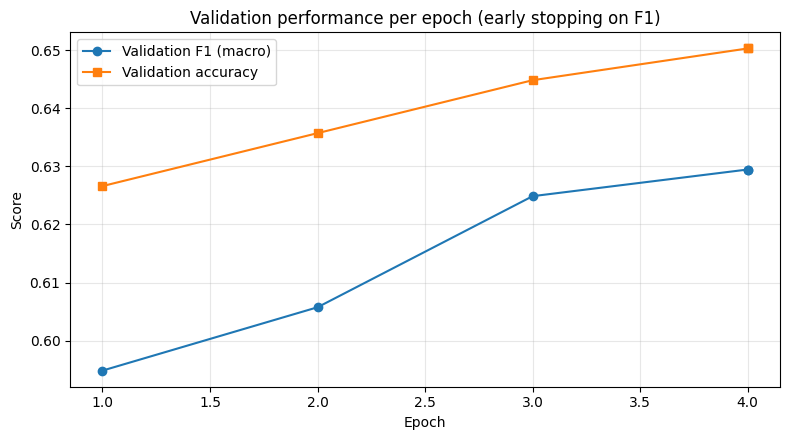

In [33]:
history = pd.DataFrame(trainer.state.log_history)
eval_hist = history.dropna(subset=["eval_f1_macro"])

plt.figure(figsize=(8, 4.5))
plt.plot(eval_hist["epoch"], eval_hist["eval_f1_macro"], marker="o", label="Validation F1 (macro)")
plt.plot(eval_hist["epoch"], eval_hist["eval_accuracy"], marker="s", label="Validation accuracy")
plt.xlabel("Epoch"); plt.ylabel("Score")
plt.title("Validation performance per epoch (early stopping on F1)")
plt.legend(); plt.grid(alpha=0.3)
save_fig("training_curve")

### Building test set with target religion labels


In [34]:
import numpy as np
import pandas as pd
os.environ["WANDB_DISABLED"] = "true"

selected_targets = [
    "target_religion_muslim",
    "target_religion_christian",
    "target_religion_jewish",
    "target_religion_atheist",
    "target_religion_buddhist"
]

def get_target_from_onehot(row):
    for col in selected_targets:
        if row.get(col, 0) == 1:
            return col
    return np.nan

tmp = test_df.copy()
tmp["target_group"] = tmp.apply(get_target_from_onehot, axis=1)
tmp = tmp.dropna(subset=["target_group"])

### Aggregating test annotations to comment level


In [35]:
def mode_or_nan(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    return s.mode().iloc[0]

test_c = (
    tmp.groupby("comment_id").agg(
        text=("text", "first"),
        mean_score=("hate_speech_score", "mean"),
        target_group=("target_group", mode_or_nan),
    )
    .reset_index()
)

test_c["label_3"] = np.select(
    [test_c["mean_score"] < -1, test_c["mean_score"] <= 0.5],
    [0, 1],
    default=2
).astype(int)

test_c["text"] = test_c["text"].map(preprocess)
test_c["label_bin"] = (test_c["label_3"] == 2).astype(int)   # hate=1, counter/neutral=0

test_c.head()

,comment_id,text,mean_score,target_group,label_3,label_bin
0,18,lol propaganda. further down in the comments i...,-1.65,target_religion_muslim,0,0
1,40,"""atheists kill their parents and family member...",0.82,target_religion_atheist,2,1
2,45,"well, he's got my support because this is anti...",-0.55,target_religion_jewish,1,0
3,87,we should flood the internet with mohammad pic...,-0.12,target_religion_muslim,1,0
4,121,men built this country while girls sat on ther...,2.68,target_religion_christian,2,1


## Preparing the test set and tokenize it.

In [36]:
from datasets import Dataset
import numpy as np

test_ds = Dataset.from_pandas(
    test_c[["text", "label_3"]].rename(columns={"label_3": "labels"})
)
test_ds = test_ds.map(tokenize, batched=True)
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

pred_out = trainer.predict(test_ds)
test_c["pred_3"] = np.argmax(pred_out.predictions, axis=1)
test_c["my_pred_bin"] = (test_c["pred_3"] == 2).astype(int)



Map:   0%|          | 0/1084 [00:00<?, ? examples/s]

### Class balance across splits

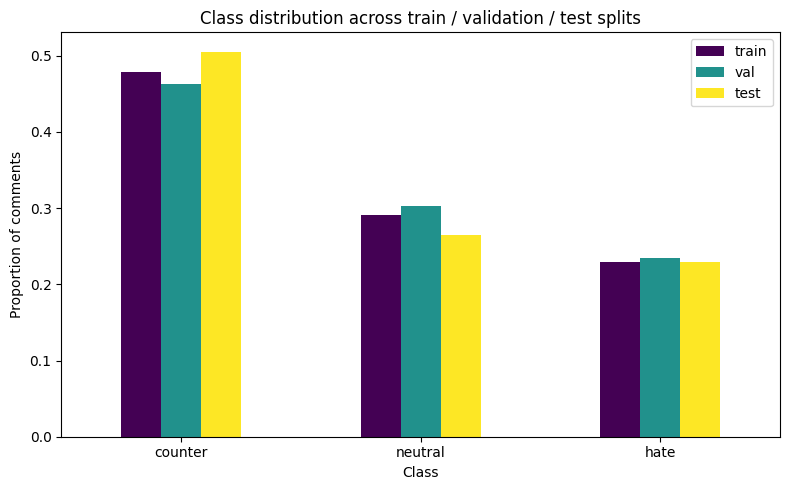

In [44]:
label_names = {0: "counter", 1: "neutral", 2: "hate"}
dist = pd.DataFrame({
    "train": train_c["label_3"].value_counts(normalize=True).sort_index(),
    "val": val_c["label_3"].value_counts(normalize=True).sort_index(),
    "test": test_c["label_3"].value_counts(normalize=True).sort_index(),
}).rename(index=label_names)

dist.plot(kind="bar", figsize=(8, 5), colormap="viridis")
plt.ylabel("Proportion of comments"); plt.xlabel("Class")
plt.title("Class distribution across train / validation / test splits")
plt.xticks(rotation=0)
save_fig("class_distribution_splits")

In [39]:
from sklearn.metrics import accuracy_score, f1_score

rows = []

for religion, subset in test_c.groupby("target_group"):
    y_true = subset["label_3"].values
    y_pred = subset["pred_3"].values
    rows.append({
        "target_religion": religion.replace("target_religion_", "").title(),
        "support": len(subset),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "f1_macro": round(f1_score(y_true, y_pred, average="macro"),    4),
        "f1_weighted": round(f1_score(y_true, y_pred, average="weighted"), 4),
    })

target_religion_results = pd.DataFrame(rows).sort_values("support", ascending=False)
target_religion_results

,target_religion,support,accuracy,f1_macro,f1_weighted
4,Muslim,510,0.6549,0.6326,0.6651
2,Christian,362,0.7127,0.6438,0.7139
3,Jewish,172,0.5930,0.5812,0.5943
0,Atheist,36,0.7778,0.7645,0.7786
1,Buddhist,4,1.0000,1.0000,1.0000


### Evaluating the best model on the test set (final metrics)

In [40]:
trainer.eval_dataset = test_ds
trainer.evaluate()

{'eval_loss': '0.7921', 'eval_accuracy': '0.6697', 'eval_f1_macro': '0.6367', 'eval_f1_weighted': '0.6749', 'eval_runtime': '6.495', 'eval_samples_per_second': '166.9', 'eval_steps_per_second': '5.235', 'epoch': '4'}


{'eval_loss': 0.7920710444450378,
 'eval_accuracy': 0.6697416974169742,
 'eval_f1_macro': 0.6366758730587029,
 'eval_f1_weighted': 0.6749012216271015,
 'eval_runtime': 6.4947,
 'eval_samples_per_second': 166.907,
 'eval_steps_per_second': 5.235,
 'epoch': 4.0}

### Detailed test report (precision/recall/F1 per class)

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

pred_out = trainer.predict(test_ds)
test_preds = np.argmax(pred_out.predictions, axis=-1)

label_names_3 = {0: "counter", 1: "neutral", 2: "hate"}

print(classification_report(
    test_c["label_3"],
    test_preds,
    target_names=[label_names_3[i] for i in sorted(label_names_3)],
    digits=4
))

print("Confusion matrix:\n", confusion_matrix(test_c["label_3"], test_preds))

              precision    recall  f1-score   support

     counter     0.8300    0.7664    0.7970       548
     neutral     0.4459    0.4878    0.4659       287
        hate     0.6288    0.6667    0.6472       249

    accuracy                         0.6697      1084
   macro avg     0.6349    0.6403    0.6367      1084
weighted avg     0.6821    0.6697    0.6749      1084

Confusion matrix:
 [[420 102  26]
 [ 75 140  72]
 [ 11  72 166]]


### Saving outputs for the comparison notebook

In [42]:
trainer.save_model(f"{SAVE_DIR}/bert_finetuned_final")
tokenizer.save_pretrained(f"{SAVE_DIR}/bert_finetuned_final")
print("Model saved to bert_finetuned_final/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to bert_finetuned_final/


In [43]:
test_c.to_csv(f"{SAVE_DIR}/test_with_my_predictions.csv", index=False)
print("Model and predictions saved to Drive")

Model and predictions saved to Drive
